# Воронка конверсии и когортный анализ

В этом ноутбуке строим воронку конверсии (view → cart → purchase) и когортный retention-анализ с использованием SQL-запросов в DuckDB.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import duckdb
con = duckdb.connect('/content/drive/MyDrive/ecommerce_project/ecommerce.duckdb')

con.execute("""
    CREATE OR REPLACE TABLE events_oct AS
    SELECT * FROM read_csv_auto('/content/drive/MyDrive/ecommerce_project/data/oct_sample.csv')
""")

con.execute("SHOW TABLES").df()

Mounted at /content/drive


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,name
0,events_oct


## Воронка конверсии

In [3]:
con.execute("""
    SELECT
        COUNT(DISTINCT CASE WHEN event_type = 'view' THEN user_id END) AS unique_viewers,
        COUNT(DISTINCT CASE WHEN event_type = 'cart' THEN user_id END) AS unique_cart_users,
        COUNT(DISTINCT CASE WHEN event_type = 'purchase' THEN user_id END) AS unique_buyers
    FROM events_oct
""").df()

,unique_viewers,unique_cart_users,unique_buyers
0,453057,50567,52224


In [4]:
con.execute("""
    SELECT
        unique_viewers,
        unique_cart_users,
        unique_buyers,
        ROUND(100.0 * unique_cart_users / unique_viewers, 2) AS view_to_cart_pct,
        ROUND(100.0 * unique_buyers / unique_cart_users, 2) AS cart_to_purchase_pct,
        ROUND(100.0 * unique_buyers / unique_viewers, 2) AS view_to_purchase_pct
    FROM (
        SELECT
            COUNT(DISTINCT CASE WHEN event_type = 'view' THEN user_id END) AS unique_viewers,
            COUNT(DISTINCT CASE WHEN event_type = 'cart' THEN user_id END) AS unique_cart_users,
            COUNT(DISTINCT CASE WHEN event_type = 'purchase' THEN user_id END) AS unique_buyers
        FROM events_oct
    )
""").df()

,unique_viewers,unique_cart_users,unique_buyers,view_to_cart_pct,cart_to_purchase_pct,view_to_purchase_pct
0,453057,50567,52224,11.16,103.28,11.53


### Выводы по воронке конверсии
На основе агрегированных SQL-данных мы получили следующие показатели воронки:
* **Уникальные зрители (view):** 453,057 пользователей (100%)
* **Уникальные пользователи с корзиной (cart):** 50,567 пользователей (Конверсия из просмотра в корзину: **11.16%**)
* **Уникальные покупатели (purchase):** 52,224 пользователей (Общая конверсия из просмотра в покупку: **11.53%**)

#### Анализ продуктовой аномалии (cart_to_purchase_pct = 103.28%):
Конверсия со второго этапа на третий превышает 100%. В изолированной математической воронке такого быть не может, но в реальном e-commerce это классическая ситуация, обусловленная следующими бизнес-факторами:

1. **Покупка в один клик (Buy Now):** На сайте интернет-магазина присутствует функционал быстрой покупки. Пользователи оформляют заказ прямо из карточки товара, минуя корзину. В логах при этом фиксируются события `view` и сразу `purchase`, а событие `cart` для этого пользователя не создается.
2. **Эффект "отложенной корзины" (Ограничение окна данных):** Наш датасет содержит данные только за октябрь 2019 года. Пользователи могли наполнить корзину в конце сентября, а завершить покупку уже в октябре. В октябрьских логах мы видим их покупку, но не видим их добавления в корзину.
3. **Особенности логирования (Специфика трекинга):** Если один и тот же пользователь заходил с разных устройств без авторизации, его действия могли записаться под разными сессиями, либо логирование события добавления в корзину работало сбоями на определенных типах устройств/платформ.

**Бизнес-вывод:** Конверсия из просмотра в корзину (11.16%) является относительно невысокой. Основная точка роста для бизнеса — стимулировать пользователей чаще добавлять товары в корзину (работа с рекомендательными системами, интерфейсом карточки товара, акциями). При этом этап перехода к оплате работает отлично за счет альтернативных путей заказа (купить в 1 клик).

## Когортный анализ (Weekly Retention Rate)

**Retention Rate (Коэффициент удержания)** — важнейшая продуктовая метрика, которая показывает, возвращаются ли пользователи в магазин.

Поскольку наш датасет ограничен октябрем 2019 года, мы будем рассчитывать **недельный Retention**. Мы разобьем пользователей на группы (когорты) по **неделе их первого действия**, а затем посчитаем, какой процент из них возвращался на сайт на 1-й, 2-й, 3-й и 4-й неделе своего «интернет-жизненного цикла».

### Логика расчета в SQL (используем CTE):
1. `user_cohorts` — для каждого уникального пользователя находим дату его самого первого действия в октябре и округляем её до начала недели (`DATE_TRUNC`). Это «дата рождения» когорты.
2. `cohort_sizes` — считаем, сколько всего уникальных пользователей «родилось» в каждую конкретную неделю (базовый размер когорты для деления).
3. `retention_counts` — соединяем (`JOIN`) таблицу «рождения» с таблицей всех действий пользователей. С помощью функции `DATEDIFF` считаем разницу в неделях между текущим действием и неделей когорты.
4. В финальном запросе объединяем данные и рассчитываем процент удержания: `(Количество активных пользователей в эту неделю / Размер исходной когорты) * 100`.

In [5]:
# 1. Неделя самой первой активности для каждого пользователя
# 2. Размер каждой когорты (количество уникальных пользователей в ней)
# 3. Возвраты пользователей по неделям
# 4. Финальный расчет: объединяем данные и переводим в проценты Retention Rate
cohort_query = """
WITH user_cohorts AS (
    SELECT
        user_id,
        DATE_TRUNC('week', MIN(CAST(event_time AS TIMESTAMP))) AS cohort_week
    FROM events_oct
    GROUP BY user_id
),

cohort_sizes AS (
    SELECT
        cohort_week,
        COUNT(DISTINCT user_id) AS cohort_size
    FROM user_cohorts
    GROUP BY cohort_week
),

retention_counts AS (
    SELECT
        uc.cohort_week,
        DATEDIFF('week', uc.cohort_week, DATE_TRUNC('week', CAST(e.event_time AS TIMESTAMP))) AS period_week,
        COUNT(DISTINCT e.user_id) AS active_users
    FROM user_cohorts uc
    JOIN events_oct e ON uc.user_id = e.user_id
    GROUP BY uc.cohort_week, period_week
)

SELECT
    r.cohort_week,
    cs.cohort_size,
    r.period_week,
    r.active_users,
    ROUND(100.0 * r.active_users / cs.cohort_size, 2) AS retention_pct
FROM retention_counts r
JOIN cohort_sizes cs ON r.cohort_week = cs.cohort_week
WHERE r.period_week >= 0
ORDER BY r.cohort_week, r.period_week;
"""

df_cohorts = con.execute(cohort_query).df()
df_cohorts

,cohort_week,cohort_size,period_week,active_users,retention_pct
0,2019-09-30,127819,0,127819,100.00
1,2019-09-30,127819,1,45623,35.69
2,2019-09-30,127819,2,41149,32.19
3,2019-09-30,127819,3,35589,27.84
4,2019-09-30,127819,4,22297,17.44
5,2019-10-07,113065,0,113065,100.00
6,2019-10-07,113065,1,30675,27.13
7,2019-10-07,113065,2,24847,21.98
8,2019-10-07,113065,3,14410,12.74
9,2019-10-14,92550,0,92550,100.00


In [6]:
import pandas as pd

# 1. Экспорт когорт по неделям
df_cohorts_export = df_cohorts.copy()
df_cohorts_export['cohort_week'] = df_cohorts_export['cohort_week'].dt.strftime('%Y-%m-%d')
df_cohorts_export.to_csv('datalens_cohorts.csv', index=False)

# 2. Средний/медианный чек на уровне заказа (схлопываем товары по сессии)
aov_query = """
WITH order_values AS (
    SELECT user_session, SUM(price) AS order_value
    FROM events_oct
    WHERE event_type = 'purchase'
    GROUP BY user_session
)
SELECT
    ROUND(AVG(order_value), 2) AS avg_order_value,
    ROUND(MEDIAN(order_value), 2) AS median_order_value
FROM order_values
"""
df_aov = con.execute(aov_query).df()

# 3. Сводка ключевых KPI в одну строку
kpi_summary = pd.DataFrame([{
    'total_users': 453057,
    'total_buyers': 52224,
    'repeat_buyer_rate_pct': 32.34,
    'median_days_to_second_purchase': 2.0,
    'avg_days_to_second_purchase': 4.4,
    'avg_order_value': df_aov['avg_order_value'][0],
    'median_order_value': df_aov['median_order_value'][0]
}])
kpi_summary.to_csv('datalens_kpi_summary.csv', index=False)
print(kpi_summary)

   total_users  total_buyers  repeat_buyer_rate_pct  \
0       453057         52224                  32.34   

   median_days_to_second_purchase  avg_days_to_second_purchase  \
0                             2.0                          4.4   

   avg_order_value  median_order_value  
0           365.19              193.03  


### Анализ результатов когортного исследования

На основе полученной SQL-матрицы удержания (Retention Rate) можно сделать следующие критически важные выводы для бизнеса:

1. **Естественный отток аудитории:** Для базовой когорты (2019-09-30) наблюдается стандартное для e-commerce постепенное снижение удержания с 35.69% на 1-й неделе до 17.44% на 4-й неделе.
2. **Аномальное ухудшение качества удержания новых когорт (Product Warning):**
   При анализе метрики **Week 1 Retention** (возврат на следующую неделю после первого визита) выявлен опасный негативный тренд:
   * Когорта 30 сентября: **35.69%**
   * Когорта 7 октября: **27.13%**
   * Когорта 14 октября: **22.33%**
   * Когорта 21 октября: **12.52%**

**Бизнес-диагноз:** Продукт стремительно теряет способность удерживать новых пользователей. Каждый новый поток клиентов адаптируется и возвращается значительно хуже предыдущего (падение Week 1 Retention почти в 3 раза за месяц).

**Рекомендации для продуктовой команды (Что проверять дальше):**
* Совместно с отделом маркетинга проанализировать каналы привлечения за октябрь. Возможно, в конце месяца был закуплен дешевый нецелевой трафик.
* Проверить логи релизов разработки на неделях от 7 и 14 октября. Требуется убедиться, что не было технических сбоев при регистрации или первом заказе для новых пользователей.

### Визуализация когортной матрицы (Retention Heatmap)

Чтобы сделать результаты исследования наглядными для продуктовой команды, построим **тепловую карту (Heatmap)** с помощью библиотек `seaborn` и `matplotlib`.

Перед построением графика нам необходимо трансформировать данные:
* SQL вернул нам данные в «длинном» формате (каждая неделя каждого удержания — это отдельная строка).
* Для построения тепловой карты нам нужен «широкий» формат (матрица/сетка), где строки — это когорты, столбцы — недели жизни, а в ячейках на пересечении лежит процент удержания. Для этого мы применим метод `.pivot()` в Pandas.

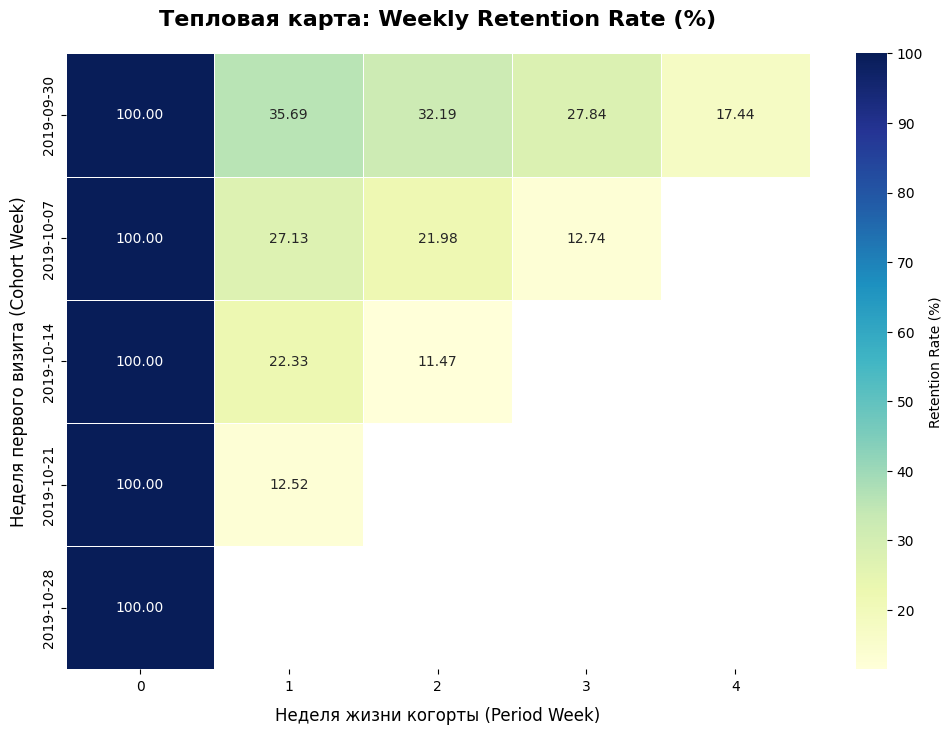

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

df_cohorts['cohort_week_str'] = df_cohorts['cohort_week'].dt.strftime('%Y-%m-%d')
retention_matrix = df_cohorts.pivot(index='cohort_week_str', columns='period_week', values='retention_pct')

plt.figure(figsize=(12, 8))
plt.title('Тепловая карта: Weekly Retention Rate (%)', fontsize=16, fontweight='bold', pad=20)

sns.heatmap(retention_matrix, annot=True, fmt='.2f', cmap='YlGnBu', cbar_kws={'label': 'Retention Rate (%)'}, linewidths=.5)

plt.xlabel('Неделя жизни когорты (Period Week)', fontsize=12, labelpad=10)
plt.ylabel('Неделя первого визита (Cohort Week)', fontsize=12, labelpad=10)

plt.show()

## Постановка бизнес-проблемы

Только сейчас, увидев фактическую динамику в данных, можно сформулировать проблему:

> **Удержание новых пользователей внутри месяца стремительно ухудшается.** Week 1 Retention упал с 35.69% (когорта 30 сентября) до 22.33% (когорта 14 октября) — каждая следующая недельная когорта новых пользователей возвращается заметно хуже предыдущей.
>
> *Оговорка по данным:* цифра по когорте 21 октября (12.52%) требует осторожной интерпретации — её "неделя 1" приходится на 28 окт–3 ноя, а датасет заканчивается 31 октября. Окно наблюдения для этой когорты неполное, поэтому фактическое retention здесь может быть несколько выше наблюдаемого.

Это и есть бизнес-проблема, на которую отвечает оставшаяся часть исследования: проверим, какие факторы — стоимость и бренд первой покупки, глубина просмотра каталога — статистически связаны с возвратом пользователя, и дадим рекомендации.

## Сколько повторных покупок на самом деле были сделаны в рамках той же самой сессии (в одном чеке)


In [2]:
print("Анализ дублирования покупок внутри одной сессии:")

con.execute("""
    WITH ranked AS (
        SELECT
            user_id,
            user_session,
            event_time,
            ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY event_time) AS rn
        FROM events_oct
        WHERE event_type = 'purchase'
    )
    SELECT
        SUM(CASE WHEN r1.user_session = r2.user_session THEN 1 ELSE 0 END) AS same_session_purchases,
        COUNT(*) AS total_second_purchases,
        ROUND(100.0 * SUM(CASE WHEN r1.user_session = r2.user_session THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_fake_repeats
    FROM ranked r1
    JOIN ranked r2 ON r1.user_id = r2.user_id AND r1.rn = 1 AND r2.rn = 2
""").df()

Анализ дублирования покупок внутри одной сессии:


,same_session_purchases,total_second_purchases,pct_fake_repeats
0,5496.0,19873,27.66


### Вывод по структуре данных и повторным покупкам

Проверка структуры событий `purchase` показала важную методологическую особенность датасета:
* **27.66%** от всех зафиксированных «вторых покупок» совершаются внутри той же самой пользовательской сессии (`user_session`).

> **Бизнес-вывод:** Почти треть «повторных» покупок — это не реальное возвращение лояльного клиента на платформу, а покупка нескольких товаров в одном чеке (multi-item checkout), например, смартфона и аксессуара к нему.
>
> Чтобы метрики `Repeat buyer pct` и `Time-to-second-purchase` не переоценивали лояльность аудитории, при расчёте продуктовых метрик воронки необходимо предварительно агрегировать транзакции до уровня уникальных сессий (`user_session`), рассматривая их как единый заказ.

## Анализ повторных покупок и метрики Time-to-Second-Purchase

Для бизнеса критически важно понимать не только то, возвращаются ли пользователи на сайт (общее удержание), но и совершают ли они повторные транзакции, и сколько времени проходит между первой и второй покупками. Это позволяет оптимизировать триггерные маркетинговые рассылки.

**Важное методологическое исправление:** Поскольку логи имеют товарную гранулярность (один чек на 3 товара генерирует 3 строки `purchase` в одну секунду), прямой расчет по строкам завысит лояльность. Поэтому перед расчетом мы предварительно агрегируем данные до уровня уникальных сессий-заказов.

Для расчета мы применим оконную функцию `ROW_NUMBER()`:
1. Схлопнем покупки внутри одной сессии `user_session` в один единый заказ.
2. Разделим данные по пользователям (`PARTITION BY user_id`).
3. Отсортируем уникальные заказы по времени (`ORDER BY order_time`).
4. С помощью `LEFT JOIN` сопоставим первый заказ (номер 1) со вторым (номер 2) для каждого юзера и найдем разницу в днях.

In [3]:
# 1. Схлопываем строки товаров из одной сессии в один единый заказ
# 2. Нумеруем реальные уникальные заказы для каждого пользователя по порядку
# 3. Выделяем только самые первые заказы пользователей
# 4. Выделяем только вторые заказы пользователей (настоящие повторные покупки)
# 5. Объединяем данные и считаем продуктовые метрики

time_to_purchase_query = """
WITH unique_orders AS (
    SELECT
        user_id,
        user_session,
        MIN(CAST(event_time AS TIMESTAMP)) AS order_time
    FROM events_oct
    WHERE event_type = 'purchase'
    GROUP BY user_id, user_session
),

ranked_purchases AS (
    SELECT
        user_id,
        order_time AS purchase_time,
        ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY order_time) AS purchase_number
    FROM unique_orders
),

first_purchases AS (
    SELECT user_id, purchase_time AS first_time
    FROM ranked_purchases
    WHERE purchase_number = 1
),

second_purchases AS (
    SELECT user_id, purchase_time AS second_time
    FROM ranked_purchases
    WHERE purchase_number = 2
)

SELECT
    COUNT(fp.user_id) AS total_buyers,
    COUNT(sp.user_id) AS repeat_buyers,
    ROUND(100.0 * COUNT(sp.user_id) / COUNT(fp.user_id), 2) AS repeat_buyer_pct,

    ROUND(AVG(DATEDIFF('day', fp.first_time, sp.second_time)), 1) AS avg_days_to_second_purchase,
    MEDIAN(DATEDIFF('day', fp.first_time, sp.second_time)) AS median_days_to_second_purchase
FROM first_purchases fp
LEFT JOIN second_purchases sp ON fp.user_id = sp.user_id;
"""

df_time_to_purchase = con.execute(time_to_purchase_query).df()
df_time_to_purchase

,total_buyers,repeat_buyers,repeat_buyer_pct,avg_days_to_second_purchase,median_days_to_second_purchase
0,52224,16887,32.34,4.4,2.0


### Выводы по анализу повторных покупок (Time-to-Second-Purchase)

После методологической очистки данных от «ложных» повторных покупок (multi-item checkouts), мы получили реальную транзакционную картину за октябрь 2019 года:

1. **Скорректированный уровень лояльности (Repeat Buyer Rate = 32.34%):** Из 52 224 уникальных покупателей 16 887 совершили два и более *разных* заказа в течение месяца. Показатель около 32% для e-commerce в рамках одного месяца всё еще остаётся очень высоким и подтверждает сильную удерживающую способность платформы, но теперь эта метрика не завышена искусственно.
2. **Реальное «Горячее окно» повторных покупок:**
   * Среднее время до второго заказа: **4.4 дня**
   * Медианное время до второго заказа: **2.0 дня**
   
   **Бизнес-интерпретация:** Медиана в 2.0 дня означает, что ровно половина клиентов, совершивших повторный заказ, делают его в первые 48 часов после первой покупки. Среднее значение (4.4 дня) смещено в большую сторону из-за «длинного хвоста» пользователей, возвращающихся спустя недели.

### Продуктовые рекомендации:
* **Оптимизация окна триггерных коммуникаций:** Основной фокус маркетинга по стимулированию второго заказа должен быть смещен на окно в **24–48 часов** после первой покупки. Эффективные механики: email/push с подборкой аксессуаров к купленному товару или персонализированный купон на скидку, сгорающий через 3 дня.
* **Анализ паттерна «дозакупки»:** Так как 50% честных повторных заказов происходят в течение 2 дней, это может указывать на паттерн «вспомнил, что забыл купить» (например, заказал телефон, а через день вернулся за чехлом или защитным стеклом). Стоит внедрить блок рекомендаций сопутствующих товаров прямо на этапе оформления первого чека (UX/UI корзины), чтобы поднимать средний чек (AOV) сразу, не дожидаясь, пока пользователь созреет на вторую сессию.

## RFM-сегментация клиентов

**RFM-анализ** — это метод сегментации пользователей по трем ключевым бизнес-метрикам:
* **Recency (Давность):** Сколько дней прошло с момента последней покупки клиента до конца месяца.
* **Frequency (Частота):** Сколько *уникальных заказов (сессий с покупками)* совершил клиент за октябрь.
* **Monetary (Деньги):** Какую суммарную выручку принес данный клиент.

**Важная очистка данных:** Для расчёта метрики `Frequency` мы используем `COUNT(DISTINCT user_session)` вместо `COUNT(*)`. Это позволяет оценивать именно частоту возвращения клиента за покупками, исключая искажения от многотоварных чеков (когда покупка 5 чехлов в одном заказе считывалась как 5 отдельных покупок).

Каждому клиенту мы присвоим оценку от 1 (худший показатель) до 3 (лучший показатель) с помощью аналитической оконной функции `NTILE(3)`. Объединив эти три оценки, мы получим финальный сегмент пользователя (например, 333 — VIP-клиенты, 111 — ушедшие однократные клиенты).

За дату отсчета для метрики Recency возьмем следующий день после окончания логирования датасета — 1 ноября 2019 года.

In [4]:
# 1. Считаем базовые метрики для каждого уникального покупателя (схлопывая товары в заказы)
# 2. С помощью NTILE делим пользователей на 3 группы по каждой метрике
# 3. Склеиваем оценки в единый RFM-код и выводим первые результаты

rfm_query = """
WITH user_rfm_metrics AS (
    SELECT
        user_id,
        DATEDIFF('day', MAX(CAST(event_time AS TIMESTAMP)), '2019-11-01') AS recency,
        COUNT(DISTINCT user_session) AS frequency,
        SUM(price) AS monetary
    FROM events_oct
    WHERE event_type = 'purchase'
    GROUP BY user_id
),

rfm_scores AS (
    SELECT
        user_id,
        recency,
        frequency,
        monetary,
        NTILE(3) OVER (ORDER BY recency DESC) AS r_score,
        NTILE(3) OVER (ORDER BY frequency ASC) AS f_score,
        NTILE(3) OVER (ORDER BY monetary ASC) AS m_score
    FROM user_rfm_metrics
)

SELECT
    user_id,
    recency AS recency_days,
    frequency AS total_orders,
    ROUND(monetary, 2) AS total_spend,
    CONCAT(r_score, f_score, m_score) AS rfm_segment
FROM rfm_scores
ORDER BY total_spend DESC
LIMIT 10;
"""

df_rfm_top = con.execute(rfm_query).df()
df_rfm_top

,user_id,recency_days,total_orders,total_spend,rfm_segment
0,513117637,1,100,244500.00,333
1,553431815,2,33,118762.24,333
2,544265841,1,65,84781.78,333
3,513906722,1,69,81637.65,333
4,549109608,1,79,77702.50,333
5,514726585,1,60,71747.46,333
6,548985588,4,39,68712.62,333
7,514468999,1,35,58514.81,333
8,547972966,1,31,48868.66,333
9,513209107,1,32,48131.65,333


### Распределение клиентов по RFM-сегментам

Чтобы получить макро-представление о структуре нашей клиентской базы, сгруппируем всех покупателей по полученным RFM-кодам. Это позволит оценить долю лояльных, колеблющихся и ушедших клиентов, а также понять, на какие сегменты маркетингу стоит направить бюджет в первую очередь.

In [5]:
# Считаем базовые метрики с подсчетом частоты заказов
# Присваиваем баллы от 1 до 3
# Склеиваем баллы в сегмент
# Группируем по сегментам и считаем объемы + доли

rfm_distribution_query = """
WITH user_rfm_metrics AS (
    SELECT
        user_id,
        DATEDIFF('day', MAX(CAST(event_time AS TIMESTAMP)), '2019-11-01') AS recency,
        COUNT(DISTINCT user_session) AS frequency,
        SUM(price) AS monetary
    FROM events_oct
    WHERE event_type = 'purchase'
    GROUP BY user_id
),

rfm_scores AS (
    SELECT
        user_id,
        NTILE(3) OVER (ORDER BY recency DESC) AS r_score,
        NTILE(3) OVER (ORDER BY frequency ASC) AS f_score,
        NTILE(3) OVER (ORDER BY monetary ASC) AS m_score
    FROM user_rfm_metrics
),

rfm_segments AS (
    SELECT
        CONCAT(r_score, f_score, m_score) AS rfm_segment
    FROM rfm_scores
)

SELECT
    rfm_segment,
    COUNT(*) AS user_count,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER(), 2) AS user_pct
FROM rfm_segments
GROUP BY rfm_segment
ORDER BY user_count DESC;
"""

df_rfm_dist = con.execute(rfm_distribution_query).df()
df_rfm_dist

,rfm_segment,user_count,user_pct
0,333,5136,9.83
1,111,4851,9.29
2,112,4021,7.70
3,321,3655,7.00
4,233,3477,6.66
5,322,3131,6.00
6,221,2528,4.84
7,211,2435,4.66
8,222,2254,4.32
9,113,2101,4.02


### Итоговый стратегический анализ клиентской базы (RFM-выводы)

На основе скорректированного распределения 52 224 покупателей по 27 RFM-сегментам (где метрика Frequency очищена от эффекта многотоварных чеков) сформирована точная матрица ценности клиентов и предложены следующие маркетинговые стратегии:

* **VIP-сегмент (Код 333 | 9.83% базы | 5 136 человек):**
  * **Бизнес-значимость:** Самая ценная доля аудитории со сверхвысокой доходностью, высокой частотой заказов и свежей активностью.
  * **Стратегия:** Удержание без прямого демпинга (скидок). Фокус на закрытые программы лояльности, реферальные системы, приоритетную поддержку и премиальный персонализированный сервис.
  
* **Зона критического риска / Отток лояльных (Коды 233 и 133 | 10.36% базы | 5 409 человек):**
  * **Бизнес-значимость:** Клиенты, которые исторически покупали часто и приносили много денег, но перестали совершать заказы в последние 1–3 недели.
  * **Стратегия (Высокий приоритет):** Срочная реактивация. Сегменту 233 (не покупали около недели) требуется мягкое напоминание о продукте (push-нотификации с брошенными корзинами или подборками новинок). Сегменту 133 (молчат больше двух недель) необходим сильный финансовый стимул — персональный промокод с ограниченным сроком действия, так как они находятся на грани безвозвратной потери.
  
* **Потенциальные лидеры (Коды 321, 322 | 13.00% базы | 6 786 человек):**
  * **Бизнес-значимость:** Наш главный актив для роста. Это новые или относительно новые клиенты, которые пришли недавно, совершили 1–2 заказа, но уже показали хороший чек.
  * **Стратегия:** Стимулирование повторных продаж. Учитывая наши выводы из анализа Time-to-Second-Purchase, их нужно «догревать» в первые 48 часов после покупки с помощью триггерных цепочек (cross-sell сопутствующих товаров, рекомендации аксессуаров).
  
* **Уснувшие однократные клиенты (Коды 111, 112 | 16.99% базы | 8 872 человека):**
  * **Бизнес-значимость:** Низкомаржинальный сегмент. Пользователи, совершившие всего один заказ в начале октября и больше не возвращавшиеся.
  * **Стратегия:** Минимизация маркетинговых расходов. Прямые платные коммуникации (SMS, звонки) по ним экономически нецелесообразны. Включать их только в массовые бесплатные email-рассылки в рамках глобальных распродаж.

# Общие выводы и итоги этапа SQL-аналитики

В ходе комплексного исследования транзакционной активности и поведения пользователей e-commerce платформы за октябрь 2019 года были решены три ключевые задачи: проведен когортный анализ удержания, скорректированы искажения в продуктовых метриках и сформирована RFM-сегментация клиентской базы.

---

### 1. Методологический инсайт: Ловушка гранулярности логов
Важнейшим этапом работы стало обнаружение особенности структуры данных: логи пишутся на уровне товара (product-level), а не заказа.
* **27.66%** «вторых покупок» при расчете «в лоб» оказались покупками нескольких товаров в рамках одного чека (одной сессии).
* Без предварительной агрегации данных до уровня уникальных сессий (`user_session`), базовые метрики лояльности были бы **искусственно завышены на ~28%**, что привело бы к ложным управленческим решениям.

### 2. Скорректированные продуктовые метрики (Честные цифры)
После очистки данных от транзакционного шума мы получили реальную картину:
* **Честный Repeat Buyer Rate (Доля повторных покупателей):** Составил **32.34%** (вместо ошибочных 38.05%). Каждый третий покупатель возвращается за вторым заказом в течение месяца.
* **Реальное «Горячее окно» (Time-to-Second-Purchase):** Медианное время между первым и вторым заказом составляет **2.0 дня**, а среднее — **4.4 дня**. Это доказывает, что если возврат за повторной покупкой происходит, то он концентрируется в первые 48 часов после первого контакта.
* **Проблема Retention (Удержание):** Когортный анализ выявил опасный тренд — Week 1 Retention новых пользователей, пришедших в конце месяца, упал с **35.69% до 22.33%**. Платформа начинает терять входящий трафик значительно быстрее.

### 3. Стратегическая структура клиентской базы (RFM-анализ)
Сегментация пользователей по очищенной частоте заказов (`Frequency`) определила четыре фокусные зоны для маркетинга:
1. **VIP-клиенты (Сегмент 333 | 9.83% базы):** Стабильное ядро бизнеса с высокой частотой и чеком. Требуют удержания через нематериальную лояльность (персональный сервис, ранний доступ к новинкам).
2. **Зона риска / Отток лояльных (Сегмент 233 | 6.66% базы):** Клиенты, которые покупали много, но начали «остывать» (не было заказов около недели). Требуют **немедленной автоматической реактивации** через триггерные push-уведомления.
3. **Потенциальные лидеры (Сегменты 321, 322 | 13.00% базы):** Свежие клиенты с хорошим чеком, сделавшие 1–2 заказа. Это главный источник роста базы. Их необходимо «догревать» сопутствующими товарами (cross-sell) строго в выявленное нами 48-часовое «горячее окно».
4. **Уснувшие однократные (Сегмент 111 | 19.29% базы):** Самый массовый и низкомаржинальный сегмент (купили 1 раз в начале месяца и ушли). Взаимодействие только в рамках бесплатных массовых рассылок.

---

## Переход в Ноутбук 03

SQL-аналитика помогла локализовать проблемы: **удержание падает, но те, кто готов купить повторно, делают это очень быстро (в течение 2 дней), при этом формируя ценные когорты потенциальных лидеров (13%)**.

Чтобы превратить эти инсайты в конкретные продуктовые фичи, на следующем этапе (**Ноутбук 03: Проверка статистических гипотез**) мы перейдем к методам математической статистики на Python. Мы проверим:
1. Влияет ли глубина взаимодействия с карточками товаров (просмотры, добавления в корзину) в первой сессии на итоговую конверсию в покупателя.
2. Существует ли статистически значимая разница в среднем чеке между пользователями разных поведенческих когорт.
3. Какие именно триггеры определяют переход пользователя из категории «одноразовый покупатель» в категорию «потенциальный лидер».